In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math as maths
import torch, torch.nn as nn
import pandas as pd
import copy
import xarray as xr
import os

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

attempt = 1

Using GPU


# Data loading and visualisation 

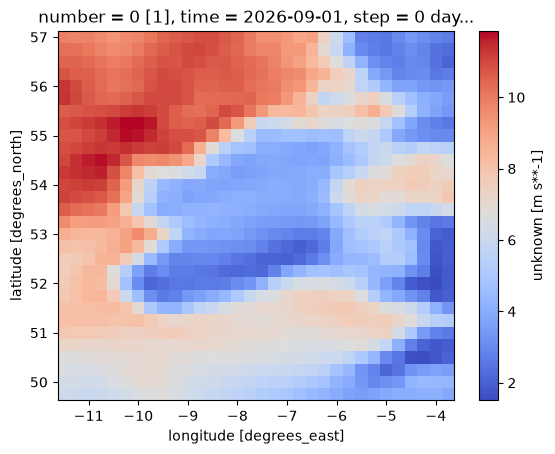

In [2]:
ds = xr.open_dataset(f"project3_data{attempt}.grib", engine="cfgrib")
#print(ds.head)
min_longitude = ds.longitude.values[2]
max_longitude = ds.longitude.values[-1]

cropped_ds = ds.sel(longitude=slice(ds.longitude.values[2], ds.longitude.values[-1]))
#print(cropped_ds.longitude.values)
#print(cropped_ds.head)
data = cropped_ds

#print(data.v10[0])
test_v = data.v10[0]
test_u = data.u10[0]
test_plot = np.sqrt(test_v**2 + test_u**2)

test_plot.plot(cmap = 'coolwarm')
plt.show()





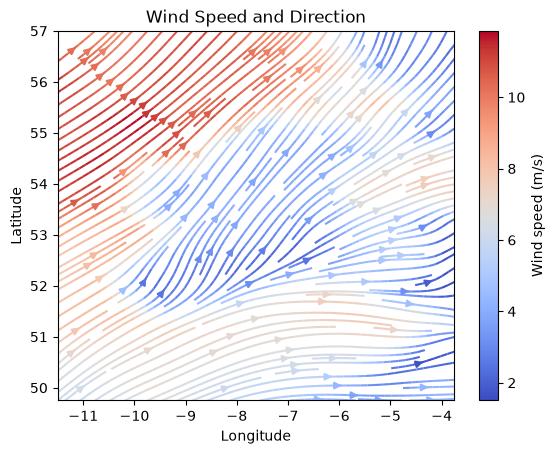

In [3]:
x = data.longitude.values
y = data.latitude.values[::-1]

xx, yy = np.meshgrid(x, y)
u = data.u10[0][:][::-1]
v = data.v10[0][:][::-1]

#print(xx.shape, yy.shape, u.shape, v.shape)



u_array = np.asarray(u, dtype=float)
v_array = np.asarray(v, dtype=float)
speed = np.hypot(u_array, v_array)

plt.streamplot(
    xx,
    yy,
    u_array,
    v_array,
    color=speed,
    cmap="coolwarm",
    density=1.8
)

plt.colorbar(label="Wind speed (m/s)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Wind Speed and Direction")
plt.show()


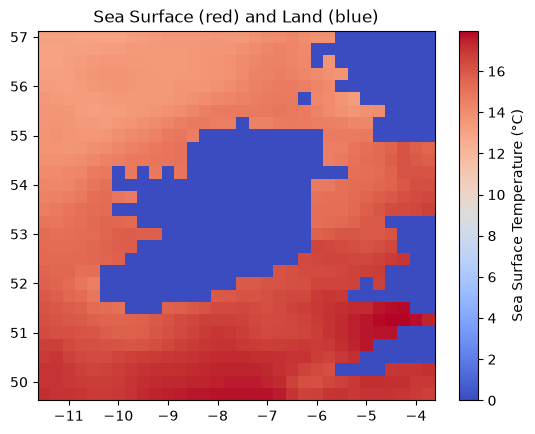

In [4]:
sea_temp = xr.open_dataset(f"sea_temp.grib", engine="cfgrib")
sea_temp_cropped = sea_temp.sel(longitude=slice(min_longitude, max_longitude))
#print(sea_temp_cropped.head)
sst = np.nan_to_num(np.asarray(sea_temp_cropped.sst[:].values) - 273.15)
#print(sst[:,:])
fig, ax = plt.subplots()
sst_plot = ax.pcolormesh(sea_temp_cropped.longitude.values, sea_temp_cropped.latitude.values, 
                         sst, cmap="coolwarm", shading="nearest")
plt.colorbar(sst_plot, ax=ax, label='Sea Surface Temperature (°C)')
plt.title('Sea Surface (red) and Land (blue)')
plt.show()

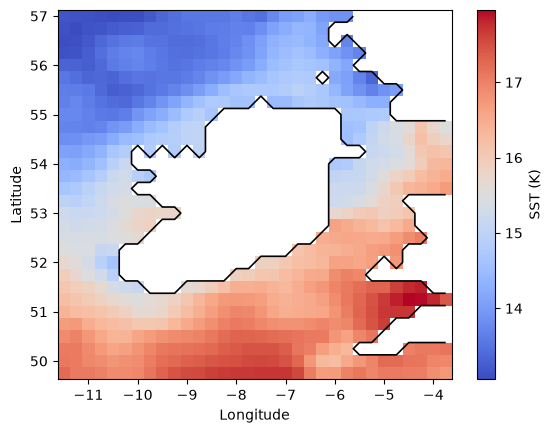

In [5]:
# Land mask: SST is NaN over land (0 after nan_to_num)
sst_lon = sea_temp_cropped.longitude.values
sst_lat = sea_temp_cropped.latitude.values
land_mask = np.isnan(sea_temp_cropped.sst.values).astype(float)

def plot_coastline(ax=None, color="black", linewidth=1.2):
    """Draw the land/sea boundary (0.5 contour of the land mask) on ax."""
    if ax is None:
        ax = plt.gca()
    ax.contour(sst_lon, sst_lat, land_mask, levels=[0.5], colors=color, linewidths=linewidth)

fig, ax = plt.subplots()
sst_plot = ax.pcolormesh(sst_lon, sst_lat, np.where(land_mask == 1, np.nan, sst), cmap="coolwarm", shading="nearest")
plot_coastline(ax)
fig.colorbar(sst_plot, label="SST (K)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
plt.show()

In [6]:
print(str(data.time.values[0]))


2026-09-01T00:00:00.000000000


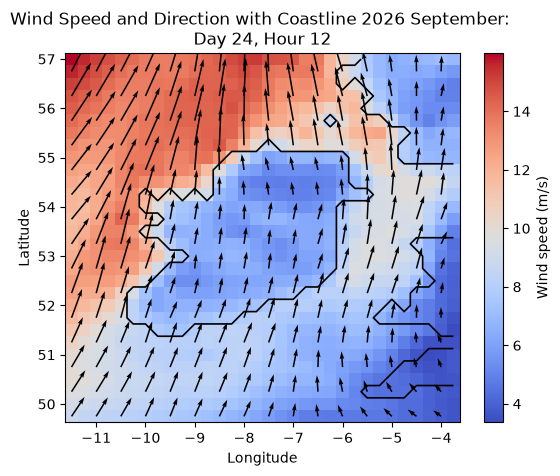

In [7]:

x = data.longitude.values
y = data.latitude.values[::-1]


xx, yy = np.meshgrid(x, y)

rand_idx = np.random.randint(0, len(data.time.values))

def create_image(idx, step = 2):
    u = data.u10[idx][:][::-1]
    v = data.v10[idx][:][::-1]
    date = str(data.time.values[idx])
    speed = np.hypot(u, v)

    fig, ax = plt.subplots()
    
    wind_plot = ax.pcolormesh(xx, yy, speed, cmap="coolwarm", shading="nearest")
    plot_coastline(ax)
    fig.colorbar(wind_plot, label="Wind speed (m/s)")
    ax.quiver(xx[::step, ::step], yy[::step, ::step], u[::step, ::step],
               v[::step, ::step], color="black", scale=150)
    
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal")
    ax.set_title("Wind Speed and Direction with Coastline 2026 September: \n" + f"Day {date[8:10]}, Hour {date[11:13]}")
    #plt.show()
    return fig


fig = create_image(rand_idx, step=2)

In [8]:
import io
from PIL import Image

gif_name = "Wind_velocity.gif"
frame_step = 6        # use every 6th time step (data is hourly) to keep the file small
gif_size = (480, 360) # downscale frames so the GIF renders in markdown

def fig_to_image(fig):
    """Render a matplotlib figure to a resized PIL Image."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png")
    buf.seek(0)
    return Image.open(buf).convert("RGB").resize(gif_size, Image.LANCZOS)

if not os.path.isfile(gif_name):
    frames = []
    for i in range(0, len(data.time.values), frame_step):
        fig = create_image(i, step=2)
        frames.append(fig_to_image(fig))
        plt.close(fig)  # Close the figure to free memory

    # Share one 128-colour palette across frames to cut file size
    palette = frames[0].quantize(colors=128)
    frames = [f.quantize(palette=palette, dither=Image.Dither.NONE) for f in frames]

    frames[0].save(
        gif_name,
        save_all=True,
        append_images=frames[1:],
        duration=300,
        loop=0,
        optimize=True
    )
    print(f"Saved {gif_name} ({len(frames)} frames, {os.path.getsize(gif_name) / 1e6:.1f} MB)")
else:
    print(f"{gif_name} already exists. Skipping GIF creation.")


Wind_velocity.gif already exists. Skipping GIF creation.


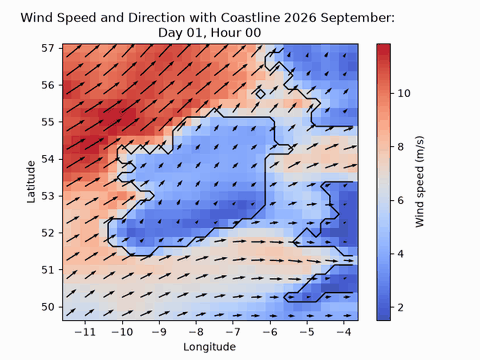

In [ ]:
from IPython import display
display.Image(filename=gif_name)

# Begin VAE

Split randomly or by time?

In [81]:
K = 16

In [82]:
# Grid is 30 (lat) x 32 (lon); add one row top and bottom to get 32 x 32.
# 'edge' repeats the boundary row, so t2m (in Kelvin) doesn't get fake 0 K rows.
data_pad = data[["u10", "v10", "t2m"]].pad(latitude=(1, 1), mode="edge")
print(data_pad.u10.shape, data_pad.v10.shape, data_pad.t2m.shape)

(696, 32, 32) (696, 32, 32) (696, 32, 32)


In [83]:
idx = np.arange(data_pad.time.size)
train_idx = idx[idx % 8 > 0]
test_idx = idx[idx % 8 == 0]
wind_speed = np.sqrt(data_pad.v10**2 + data_pad.u10**2)



#print(data_pad.v10.shape, data_pad.u10.shape, data_pad.t2m.shape)

train_v_mean = float(np.asarray(np.mean(data_pad.v10[train_idx])))
train_u_mean = float(np.asarray(np.mean(data_pad.u10[train_idx])))
train_speed_mean = float(np.asarray(np.mean(wind_speed[train_idx])))
train_t2m_mean = float(np.asarray(np.mean(data_pad.t2m[train_idx])))

train_v_std = float(np.asarray(np.std(data_pad.v10[train_idx])))
train_u_std = float(np.asarray(np.std(data_pad.u10[train_idx])))
train_speed_std = float(np.asarray(np.std(wind_speed[train_idx])))
train_t2m_std = float(np.asarray(np.std(data_pad.t2m[train_idx])))

X_train = np.asarray(wind_speed[train_idx])
X_test = np.asarray(wind_speed[test_idx])
 

In [84]:
spe_tr = torch.from_numpy((X_train - train_speed_mean) / train_speed_std).float().unsqueeze(1)
spe_te = torch.from_numpy((X_test - train_speed_mean) / train_speed_std).float().unsqueeze(1)

spe_tr_flat = spe_tr.reshape(spe_tr.shape[0], -1)
spe_te_flat = spe_te.reshape(spe_te.shape[0], -1)

print(f"spe_tr {spe_tr.shape}, spe_te {spe_te.shape}, flattened D = {spe_tr_flat.shape[1]}," +
      f" spe_tr_flat {spe_tr_flat.shape}, spe_te_flat {spe_te_flat.shape}")

spe_tr torch.Size([609, 1, 32, 32]), spe_te torch.Size([87, 1, 32, 32]), flattened D = 1024, spe_tr_flat torch.Size([609, 1024]), spe_te_flat torch.Size([87, 1024])


In [85]:
spe_tr_np = spe_tr_flat.numpy().astype(np.float64)
spe_te_np = spe_te_flat.numpy().astype(np.float64)

pca_mean = np.mean(spe_tr_np, axis=0)
x_cen = spe_tr_np - pca_mean
U, S, Vt = np.linalg.svd(x_cen, full_matrices=False)
eig_vals = S**2 / (len(x_cen) - 1)

def pca_reconstruct(X, k):
    Z = (X - pca_mean) @ Vt[:k].T
    return Z @ Vt[:k] + pca_mean, Z

def mse(a, b):
    return np.mean((a - b) ** 2)

K = min(K, Vt.shape[0])

rec_train, Z_train = pca_reconstruct(spe_tr_np, K)
rec_test, Z_test = pca_reconstruct(spe_te_np, K)
MSE_PCA = mse(spe_te_np, rec_test)
MSE_MEAN = mse(spe_te_np, np.broadcast_to(pca_mean, spe_te_np.shape))

# Use a scalar normalization scale for formatting and RMSE reporting.
# train_speed_std is the standard deviation used to standardize the data.
sigma = train_speed_std

var_explained = eig_vals.cumsum() / eig_vals.sum()

print(f"test MSE, mean field only : {MSE_MEAN:.5f}  "
    f"(RMSE {sigma * np.sqrt(MSE_MEAN):.2f} m/s)")
print(f"test MSE, PCA k = {K}      : {MSE_PCA:.5f}  "
      f"(RMSE {sigma * np.sqrt(MSE_PCA):.2f} m/s)")



test MSE, mean field only : 0.60083  (RMSE 2.71 m/s)
test MSE, PCA k = 16      : 0.01969  (RMSE 0.49 m/s)


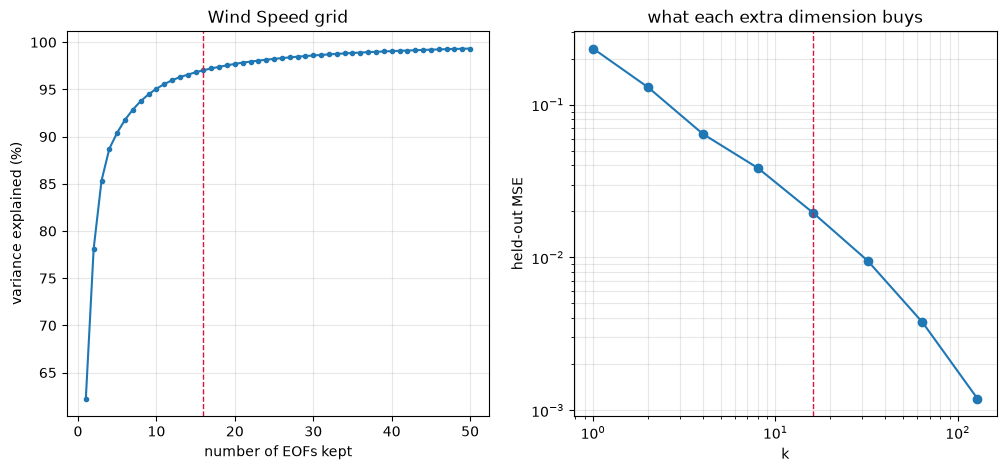

In [86]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(np.arange(1, 51), 100 * var_explained[:50], marker="o", ms=3)
ax[0].axvline(K, color="crimson", ls="--", lw=1)
ax[0].set(xlabel="number of EOFs kept", ylabel="variance explained (%)",
          title="Wind Speed grid"); ax[0].grid(alpha=0.3)

ks = [1, 2, 4, 8, 16, 32, 64, 128]
curve = [mse(spe_te_np, pca_reconstruct(spe_te_np, k)[0]) for k in ks]
ax[1].loglog(ks, curve, marker="o")
ax[1].axvline(K, color="crimson", ls="--", lw=1)
ax[1].set(xlabel="k", ylabel="held-out MSE", title="what each extra dimension buys")
ax[1].grid(alpha=0.3, which="both")


In [ ]:
class ConvVAE(nn.Module):
    def __init__(self, k=K, input_shape=(1, 32, 32),):
        super().__init__()
        self.enc_conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # 32x32 -> 16x16
            nn.Softmax2d(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),  # 16x16 -> 8x8
            nn.Softmax2d(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 8x8 -> 4x4
            nn.Softmax2d(),)
        self.mu = nn.Linear(64 * 4 * 4, k)
        self.logvar = nn.Linear(64 * 4 * 4, k)
        self.from_code = nn.Linear(k, 64 * 4 * 4)
        self.dec_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # 4x4 -> 8x8
            nn.Softmax2d(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # 8x8 -> 16x16
            nn.Softmax2d(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # 16x16 -> 32x32
            )

    def encode(self, x):
        h = self.enc_conv(x).flatten(1)
        mu = self.mu(h)
        logvar = self.logvar(h)
        return  mu, logvar

    def decode(self, z):
        h = torch.softmax(self.from_code(z).view(-1, 64, 4, 4))
        return self.dec_conv(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return self.decode(z), mu, logvar

def vae_loss(recon_x, x, mu, logvar):
    BCE = nn.functional.mse_loss(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

        
